# Data Augmentation

## Definición general

**Data Augmentation** es una técnica fundamental en el entrenamiento de redes neuronales. Consiste en generar artificialmente nuevas muestras a partir del conjunto de datos original mediante la aplicación de transformaciones geométricas o alteraciones controladas. Su objetivo principal es multiplicar la cantidad de ejemplos disponibles, ayudando al modelo a generalizar mejor ante escenarios desconocidos y reduciendo drásticamente el riesgo de sobreajuste (*overfitting*).

Esta estrategia cobra un valor incalculable en escenarios donde los ejemplos iniciales son muy limitados o cuando el proceso de generar, recolectar o etiquetar nuevos datos resulta computacional o económicamente prohibitivo (como ocurre al usar solvers exactos muy lentos para encontrar la ruta óptima de un mapa).

## Aplicación al TSP

Para el TSP, la transformación más natural, segura y efectiva es la **rotación**. La lógica subyacente es que la ruta óptima de un mapa no cambia en absoluto si giramos el mapa completo; las conexiones relativas se mantienen idénticas. Sin embargo, para la red neuronal, rotar las coordenadas 90° cambia por completo los valores numéricos de entrada.

Al forzar a la red a resolver el mismo problema geométrico desde diferentes orientaciones, le enseñamos a desarrollar **invariancia rotacional**. El modelo deja de intentar memorizar posiciones absolutas (por ejemplo, "las ciudades en la esquina superior derecha siempre se visitan primero") y se ve obligado a comprender la topología real y las distancias relativas entre los nodos.

Para poner esto en práctica, primero generamos nuestro conjunto base con 5.000 datos generados a partir de instancias con 50 ciudades:

In [8]:
from instances.instances import generate_instances

instances = generate_instances(filename="TSP50.pkl", instance_count=1000, cities=50, seed=42)

from data.generation import generate_train_data
from data.adapters.input.default import DefaultInputAdapter
from data.adapters.output.default import DefaultOutputAdapter

input_config = (DefaultInputAdapter, 50)
output_config = (DefaultOutputAdapter, 50)

generate_train_data(
    instance_file="TSP50.pkl", 
    data_filename="TSP50.h5", 
    input_adapter_config=input_config, 
    output_adapter_config=output_config,
    size=5000
)

Datos guardados en: /home/oscar/Escritorio/TSP-Framework/data/TSP50.h5 (Tamaño: 5000)


Para visualizar los efectos de esta técnica, aplicaremos 4 rotaciones (0°, 90°, 180°, 270°) sobre una instancia de nuestro conjunto de datos y graficaremos el mapa de puntos resultante. 

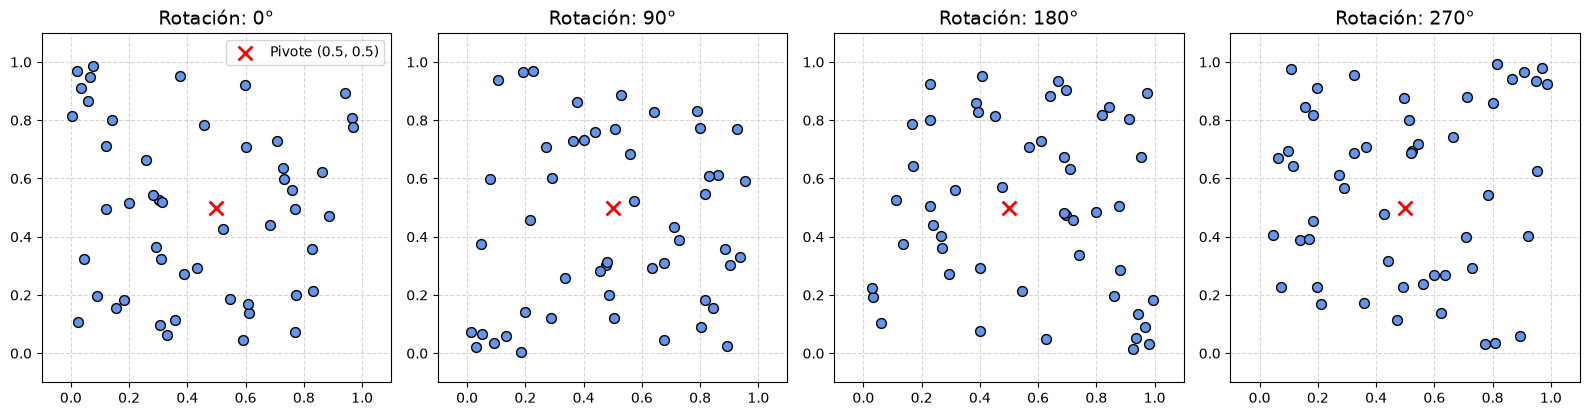

In [9]:
from data.augmentation import plot_rotations

plot_rotations(
    train_filename="TSP50.h5", 
    instance_idx=42, 
    angles=[0, 90, 180, 270]
)

Ahora, integraremos esta técnica a nuestro ciclo de preparación de datos. Una regla importante es que *data augmentation* debe aplicarse exclusivamente en el **conjunto de datos de entrenamiento**. De lo contrario, corremos el riesgo de sufrir una **fuga de datos** (*data leakage*). Si rotamos todo antes de separar los conjuntos, algunas versiones giradas de los mapas de validación terminarán en el entrenamiento. Esto es el equivalente a darle al modelo las respuestas del examen por adelantado: memorizará las rutas en lugar de aprender a calcularlas, arruinando por completo la validez de nuestras métricas.

In [ ]:
from data.preprocessing import split_dataset
from data.augmentation import augment_train_set
    
# 1. Dividir los datos originales
train_file, test_file = split_dataset("TSP50.h5", train_size=4000, seed=42)
    
# 2. Aumentar SOLAMENTE el conjunto de entrenamiento
augment_train_set(
    train_filename="TSP50.h5", 
    angles=[0, 90, 180, 270]
)

Cargando dataset original: /home/oscar/Escritorio/TSP-Framework/data/TSP50.h5
Guardando Train puro (4000 muestras) en: TSP50_train.h5
Guardando Val puro (1000 muestras) en: TSP50_val.h5
Cargando Train set base: /home/oscar/Escritorio/TSP-Framework/data/TSP50_train.h5
Aplicando rotaciones (0°, 90°, 180°, 270°)...
Ensamblando y mezclando el Train set final...
Guardando Train aumentado en: TSP50_train_aug.h5
** ¡Finalizado! El conjunto de entrenamiento creció a 16000 muestras.


Posteriormente, podemos utilizar estos datasets para entrenar el modelo como lo hemos hecho en *notebooks* anteriores.